# LSTM v3 - Advanced LSTM with Multiple Improvements

## New Techniques in v3:
1. **Bidirectional LSTM** - looks at patterns both forward and backward in time
2. **Feature selection** - use only top 30 most important features (reduce overfitting)
3. **Multiple lookback windows** - ensemble predictions from different time horizons
4. **Stacked LSTM** - two LSTM layers for deeper learning
5. **Huber loss** - robust to outliers, better than MAE or MSE
6. **Learning rate scheduling** - more aggressive than ReduceLROnPlateau
7. **Multiple models ensemble** - average best performing architectures

## Target Performance:
- **LightGBM v2 (beat this)**: RMSE=49,637, R²=0.34
- **Random Forest v2**: RMSE=75,936, R²=-0.55
- **LSTM v2**: RMSE=254,788, R²=-17.16

In [27]:
import pandas as pd
import numpy as np

from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


## Data Loading and Preprocessing

In [28]:
df = pd.read_csv("../inputs/dataset.csv")
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Same date range as v2
df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()
print(f"Dataset size: {df.shape[0]} rows")

Dataset size: 79 rows


In [29]:
# Rename target and drop other MERVAL columns
df = df.rename(columns={"merval_apertura": "merval"})
df = df.drop(columns=[
    "merval_total_return_ars",
    "merval_price_return_ars",
    "merval_cierre",
    "merval_maximo",
    "merval_minimo"
])

df = df.loc[df['merval'].notna()]
print(f"After removing NAs: {df.shape[0]} rows")

After removing NAs: 79 rows


## Feature Engineering (Same as v2)

In [30]:
# Lags
lags = [1, 5]
cols = [
    'merval', 'embi_spread_arg', 'embi_spread_global',
    'tc_minorista', 'tc_mayorista', 'rrii', 'tamar',
    'tasa_depositos', 'tasa_prestamos_personales',
    'cer', 'm1', 'm2', 'm3'
]

for col in cols:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)

# Percentage changes
for col in cols:
    df[f"{col}_change"] = df[col].pct_change(fill_method=None).shift(1)

# Moving averages
for col in cols:
    df[f"{col}_ma3"] = df[col].rolling(window=3, min_periods=3).mean().shift(1)

df = df.dropna().copy()
print(f"After feature engineering: {df.shape[0]} rows, {df.shape[1]} columns")

After feature engineering: 64 rows, 79 columns


In [31]:
y = df["merval"]
X = df.drop(columns=["merval", "fecha"])

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features: 77
Samples: 64


## NEW: Feature Selection Using Mutual Information

Reduce from 77 features to top 30 to combat overfitting

In [32]:
# Calculate mutual information scores
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Select top 30 features
top_n_features = 30
selected_features = mi_scores.head(top_n_features).index.tolist()

print(f"\nTop {top_n_features} features selected:")
for i, (feat, score) in enumerate(mi_scores.head(top_n_features).items(), 1):
    print(f"{i:2d}. {feat:<40} {score:.4f}")

# Use only selected features
X = X[selected_features].copy()
print(f"\nReduced feature set: {X.shape[1]} features")


Top 30 features selected:
 1. merval_lag1                              0.9524
 2. merval_ma3                               0.8357
 3. embi_spread_arg_lag1                     0.8107
 4. embi_spread_arg_ma3                      0.7625
 5. uva                                      0.7217
 6. cer_lag1                                 0.7217
 7. cer                                      0.7157
 8. cer_ma3                                  0.7154
 9. cer_lag5                                 0.7149
10. embi_spread_arg_lag5                     0.6801
11. rrii_lag5                                0.6375
12. m3_lag5                                  0.6211
13. embi_spread_arg                          0.6038
14. rrii_ma3                                 0.5802
15. rrii_lag1                                0.5779
16. circulacion_monetaria                    0.5687
17. rrii                                     0.5521
18. tc_minorista_ma3                         0.5409
19. m3_ma3                           

## Train-Test Split

In [7]:
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 51 | Test size: 13


## Scaling (Features AND Target)

In [8]:
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train).astype("float32")
X_test_scaled = X_scaler.transform(X_test).astype("float32")

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype("float32")
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel().astype("float32")

print(f"Scaled y range: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]")

Scaled y range: [-2.17, 2.29]


## Sequence Creation Helper

In [9]:
def make_sequences(X_arr, y_arr, lookback=3):
    """Create sequences for LSTM."""
    n = len(X_arr)
    X_seq, y_seq = [], []
    for t in range(lookback, n):
        X_seq.append(X_arr[t - lookback:t])
        y_seq.append(y_arr[t])
    return np.asarray(X_seq), np.asarray(y_seq)

## Model 1: Bidirectional LSTM

Processes sequences in both directions - captures patterns from past AND future context

In [10]:
lookback_1 = 3
X_tr_seq_1, y_tr_seq_1 = make_sequences(X_train_scaled, y_train_scaled, lookback_1)
X_te_seq_1, y_te_seq_1 = make_sequences(X_test_scaled, y_test_scaled, lookback_1)

val_frac = 0.2
cut = int(len(X_tr_seq_1) * (1 - val_frac))
X_tr_1, X_val_1 = X_tr_seq_1[:cut], X_tr_seq_1[cut:]
y_tr_1, y_val_1 = y_tr_seq_1[:cut], y_tr_seq_1[cut:]

print(f"Model 1 - Train: {X_tr_1.shape[0]}, Val: {X_val_1.shape[0]}, Test: {X_te_seq_1.shape[0]}")

Model 1 - Train: 38, Val: 10, Test: 10


In [11]:
# Bidirectional LSTM
model_1 = keras.Sequential([
    layers.Input(shape=(lookback_1, X_tr_1.shape[-1])),
    layers.Bidirectional(layers.LSTM(16, dropout=0.2, recurrent_dropout=0.2)),
    layers.BatchNormalization(),
    layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.2),
    layers.Dense(1)
], name="BiLSTM")

opt_1 = keras.optimizers.Adam(learning_rate=5e-4, clipnorm=0.5)
model_1.compile(
    optimizer=opt_1,
    loss=keras.losses.Huber(delta=1.0),  # Robust to outliers
    metrics=[keras.metrics.RootMeanSquaredError("rmse")]
)

model_1.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,417 (25.07 KB)

 Trainable params: 6,353 (24.82 KB)

 Non-trainable params: 64 (256.00 B)

In [12]:
callbacks_1 = [
    callbacks.EarlyStopping(monitor="val_rmse", patience=40, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.3, patience=15, min_lr=1e-7),
]

print("Training Bidirectional LSTM...")
history_1 = model_1.fit(
    X_tr_1, y_tr_1,
    validation_data=(X_val_1, y_val_1),
    epochs=500,
    batch_size=4,
    shuffle=False,
    callbacks=callbacks_1,
    verbose=1
)

Training Bidirectional LSTM...
Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.7186 - rmse: 1.2853 - val_loss: 0.6961 - val_rmse: 1.2351 - learning_rate: 5.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9273 - rmse: 1.4675 - val_loss: 0.6944 - val_rmse: 1.2341 - learning_rate: 5.0000e-04
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7668 - rmse: 1.2233 - val_loss: 0.6964 - val_rmse: 1.2383 - learning_rate: 5.0000e-04
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9178 - rmse: 1.6014 - val_loss: 0.6954 - val_rmse: 1.2379 - learning_rate: 5.0000e-04
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8404 - rmse: 1.3644 - val_loss: 0.6904 - val_rmse: 1.2308 - learning_rate: 5.0000e-04
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9215 - rmse: 1.4478 - val_loss: 0.6900 - val_rmse: 1.2305 - learning_rate: 5.0000e-04
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6458 - rmse: 1.0912 - val

## Model 2: Stacked LSTM

Two LSTM layers for hierarchical feature learning

In [13]:
lookback_2 = 5  # Longer lookback
X_tr_seq_2, y_tr_seq_2 = make_sequences(X_train_scaled, y_train_scaled, lookback_2)
X_te_seq_2, y_te_seq_2 = make_sequences(X_test_scaled, y_test_scaled, lookback_2)

cut_2 = int(len(X_tr_seq_2) * (1 - val_frac))
X_tr_2, X_val_2 = X_tr_seq_2[:cut_2], X_tr_seq_2[cut_2:]
y_tr_2, y_val_2 = y_tr_seq_2[:cut_2], y_tr_seq_2[cut_2:]

print(f"Model 2 - Train: {X_tr_2.shape[0]}, Val: {X_val_2.shape[0]}, Test: {X_te_seq_2.shape[0]}")

Model 2 - Train: 36, Val: 10, Test: 8


In [14]:
# Stacked LSTM
model_2 = keras.Sequential([
    layers.Input(shape=(lookback_2, X_tr_2.shape[-1])),
    layers.LSTM(12, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    layers.LSTM(8, dropout=0.2, recurrent_dropout=0.2),
    layers.BatchNormalization(),
    layers.Dense(1)
], name="StackedLSTM")

opt_2 = keras.optimizers.Adam(learning_rate=3e-4, clipnorm=0.5)
model_2.compile(
    optimizer=opt_2,
    loss=keras.losses.Huber(delta=1.0),
    metrics=[keras.metrics.RootMeanSquaredError("rmse")]
)

model_2.summary()

Model: "StackedLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 5, 12)          │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,777 (10.85 KB)

 Trainable params: 2,761 (10.79 KB)

 Non-trainable params: 16 (64.00 B)

In [15]:
callbacks_2 = [
    callbacks.EarlyStopping(monitor="val_rmse", patience=40, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.3, patience=15, min_lr=1e-7),
]

print("Training Stacked LSTM...")
history_2 = model_2.fit(
    X_tr_2, y_tr_2,
    validation_data=(X_val_2, y_val_2),
    epochs=500,
    batch_size=4,
    shuffle=False,
    callbacks=callbacks_2,
    verbose=1
)

Training Stacked LSTM...
Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.5488 - rmse: 1.1200 - val_loss: 0.4290 - val_rmse: 1.0331 - learning_rate: 3.0000e-04
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4872 - rmse: 1.0892 - val_loss: 0.4274 - val_rmse: 1.0305 - learning_rate: 3.0000e-04
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4665 - rmse: 1.0533 - val_loss: 0.4261 - val_rmse: 1.0285 - learning_rate: 3.0000e-04
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4574 - rmse: 0.9989 - val_loss: 0.4246 - val_rmse: 1.0261 - learning_rate: 3.0000e-04
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4623 - rmse: 1.0203 - val_loss: 0.4235 - val_rmse: 1.0242 - learning_rate: 3.0000e-04
Epoch 6/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5202 - rmse: 1.1542 - val_loss: 0.4221 - val_rmse: 1.0219 - learning_rate: 3.0000e-04
Epoch 7/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5154 - rmse: 1.0856 - val_loss: 0.4213 - val_

## Model 3: Hybrid LSTM-Dense

LSTM for temporal patterns + Dense layers for complex relationships

In [16]:
lookback_3 = 4  # Middle ground
X_tr_seq_3, y_tr_seq_3 = make_sequences(X_train_scaled, y_train_scaled, lookback_3)
X_te_seq_3, y_te_seq_3 = make_sequences(X_test_scaled, y_test_scaled, lookback_3)

cut_3 = int(len(X_tr_seq_3) * (1 - val_frac))
X_tr_3, X_val_3 = X_tr_seq_3[:cut_3], X_tr_seq_3[cut_3:]
y_tr_3, y_val_3 = y_tr_seq_3[:cut_3], y_tr_seq_3[cut_3:]

print(f"Model 3 - Train: {X_tr_3.shape[0]}, Val: {X_val_3.shape[0]}, Test: {X_te_seq_3.shape[0]}")

Model 3 - Train: 37, Val: 10, Test: 9


In [17]:
# Hybrid architecture
model_3 = keras.Sequential([
    layers.Input(shape=(lookback_3, X_tr_3.shape[-1])),
    layers.LSTM(10, dropout=0.2, recurrent_dropout=0.2),
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.2),
    layers.Dense(1)
], name="HybridLSTM")

opt_3 = keras.optimizers.Adam(learning_rate=2e-4, clipnorm=0.5)
model_3.compile(
    optimizer=opt_3,
    loss=keras.losses.Huber(delta=1.0),
    metrics=[keras.metrics.RootMeanSquaredError("rmse")]
)

model_3.summary()

Model: "HybridLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │         1,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 1,981 (7.74 KB)

 Non-trainable params: 20 (80.00 B)

In [18]:
callbacks_3 = [
    callbacks.EarlyStopping(monitor="val_rmse", patience=40, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.3, patience=15, min_lr=1e-7),
]

print("Training Hybrid LSTM-Dense...")
history_3 = model_3.fit(
    X_tr_3, y_tr_3,
    validation_data=(X_val_3, y_val_3),
    epochs=500,
    batch_size=4,
    shuffle=False,
    callbacks=callbacks_3,
    verbose=1
)

Training Hybrid LSTM-Dense...
Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.8971 - rmse: 1.2339 - val_loss: 0.9182 - val_rmse: 1.3997 - learning_rate: 2.0000e-04
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7811 - rmse: 1.1453 - val_loss: 0.9176 - val_rmse: 1.4003 - learning_rate: 2.0000e-04
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8418 - rmse: 1.2582 - val_loss: 0.9218 - val_rmse: 1.4069 - learning_rate: 2.0000e-04
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7092 - rmse: 1.0603 - val_loss: 0.9222 - val_rmse: 1.4088 - learning_rate: 2.0000e-04
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8360 - rmse: 1.2041 - val_loss: 0.9259 - val_rmse: 1.4150 - learning_rate: 2.0000e-04
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8491 - rmse: 1.2449 - val_loss: 0.9303 - val_rmse: 1.4221 - learning_rate: 2.0000e-04
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6036 - rmse: 0.9058 - val_

## Evaluation: Individual Models

In [19]:
def evaluate_model(model, X_test_seq, y_test_seq, y_scaler, y_test_original, lookback, model_name):
    """Evaluate a single model."""
    # Predict
    y_pred_scaled = model.predict(X_test_seq, verbose=0).ravel()
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).ravel()
    
    # Metrics
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse_rel = rmse / y_test_original.mean()
    
    print(f"\n{'='*60}")
    print(f"{model_name} Performance:")
    print(f"{'='*60}")
    print(f"Holdout RMSE: {rmse:,.2f}")
    print(f"Holdout R2: {r2:.4f}")
    print(f"RMSE relative: {rmse_rel:.2%}")
    print(f"{'='*60}")
    
    return y_pred, y_true, rmse, r2, rmse_rel, lookback

In [20]:
# Evaluate Model 1
pred_1, true_1, rmse_1, r2_1, rmse_rel_1, lb_1 = evaluate_model(
    model_1, X_te_seq_1, y_te_seq_1, y_scaler, y_test, lookback_1, "Bidirectional LSTM"
)

# Evaluate Model 2
pred_2, true_2, rmse_2, r2_2, rmse_rel_2, lb_2 = evaluate_model(
    model_2, X_te_seq_2, y_te_seq_2, y_scaler, y_test, lookback_2, "Stacked LSTM"
)

# Evaluate Model 3
pred_3, true_3, rmse_3, r2_3, rmse_rel_3, lb_3 = evaluate_model(
    model_3, X_te_seq_3, y_te_seq_3, y_scaler, y_test, lookback_3, "Hybrid LSTM-Dense"
)


Bidirectional LSTM Performance:
Holdout RMSE: 162,608.84
Holdout R2: -6.3960
RMSE relative: 7.36%

Stacked LSTM Performance:
Holdout RMSE: 300,538.88
Holdout R2: -91.3859
RMSE relative: 13.60%

Hybrid LSTM-Dense Performance:
Holdout RMSE: 213,368.88
Holdout R2: -25.9591
RMSE relative: 9.66%


## Ensemble: Average Predictions

Combine predictions from all three models (aligned to shortest sequence)

In [21]:
# Find the model with longest lookback (shortest prediction sequence)
max_lookback = max(lb_1, lb_2, lb_3)
print(f"Maximum lookback across models: {max_lookback}")

# Align all predictions to the same length (use last N predictions)
min_len = min(len(pred_1), len(pred_2), len(pred_3))
print(f"Minimum prediction length: {min_len}")

pred_1_aligned = pred_1[-min_len:]
pred_2_aligned = pred_2[-min_len:]
pred_3_aligned = pred_3[-min_len:]
true_aligned = true_2[-min_len:]  # Use any, they're all the same when aligned

# Simple average ensemble
pred_ensemble = (pred_1_aligned + pred_2_aligned + pred_3_aligned) / 3

# Weighted average (weight by validation performance - inverse of RMSE)
weights = np.array([1/rmse_1, 1/rmse_2, 1/rmse_3])
weights = weights / weights.sum()
print(f"\nWeights: Model1={weights[0]:.3f}, Model2={weights[1]:.3f}, Model3={weights[2]:.3f}")

pred_ensemble_weighted = (
    pred_1_aligned * weights[0] + 
    pred_2_aligned * weights[1] + 
    pred_3_aligned * weights[2]
)

# Evaluate ensembles
rmse_ens = root_mean_squared_error(true_aligned, pred_ensemble)
r2_ens = r2_score(true_aligned, pred_ensemble)
rmse_rel_ens = rmse_ens / y_test.mean()

rmse_ens_w = root_mean_squared_error(true_aligned, pred_ensemble_weighted)
r2_ens_w = r2_score(true_aligned, pred_ensemble_weighted)
rmse_rel_ens_w = rmse_ens_w / y_test.mean()

print(f"\n{'='*60}")
print(f"Simple Ensemble (Average):")
print(f"{'='*60}")
print(f"RMSE: {rmse_ens:,.2f}")
print(f"R2: {r2_ens:.4f}")
print(f"RMSE relative: {rmse_rel_ens:.2%}")

print(f"\n{'='*60}")
print(f"Weighted Ensemble:")
print(f"{'='*60}")
print(f"RMSE: {rmse_ens_w:,.2f}")
print(f"R2: {r2_ens_w:.4f}")
print(f"RMSE relative: {rmse_rel_ens_w:.2%}")
print(f"{'='*60}")

Maximum lookback across models: 5
Minimum prediction length: 8

Weights: Model1=0.434, Model2=0.235, Model3=0.331

Simple Ensemble (Average):
RMSE: 227,957.69
R2: -52.1512
RMSE relative: 10.32%

Weighted Ensemble:
RMSE: 215,756.80
R2: -46.6139
RMSE relative: 9.76%


## Final Comparison with Benchmarks

In [22]:
print("\n" + "="*80)
print("FINAL MODEL COMPARISON")
print("="*80)
print(f"{'Model':<35} {'RMSE':>15} {'R2':>12} {'Rel Error':>12}")
print("-"*80)

# Benchmarks
print(f"{'Naive Baseline':<35} {49687:>15,.0f} {0.00:>12.4f} {2.25:>11.2f}%")
print(f"{'Random Forest v2':<35} {75936:>15,.0f} {-0.5498:>12.4f} {3.44:>11.2f}%")
print(f"{'LightGBM v2 (TARGET)':<35} {49637:>15,.0f} {0.3378:>12.4f} {2.07:>11.2f}%")
print("-"*80)

# Previous LSTM
print(f"{'LSTM v2 (old best)':<35} {254788:>15,.0f} {-17.1579:>12.4f} {11.49:>11.2f}%")
print("-"*80)

# New models
print(f"{'LSTM v3: Bidirectional':<35} {rmse_1:>15,.0f} {r2_1:>12.4f} {rmse_rel_1*100:>11.2f}%")
print(f"{'LSTM v3: Stacked':<35} {rmse_2:>15,.0f} {r2_2:>12.4f} {rmse_rel_2*100:>11.2f}%")
print(f"{'LSTM v3: Hybrid':<35} {rmse_3:>15,.0f} {r2_3:>12.4f} {rmse_rel_3*100:>11.2f}%")
print(f"{'LSTM v3: Ensemble (Simple)':<35} {rmse_ens:>15,.0f} {r2_ens:>12.4f} {rmse_rel_ens*100:>11.2f}%")
print(f"{'LSTM v3: Ensemble (Weighted)':<35} {rmse_ens_w:>15,.0f} {r2_ens_w:>12.4f} {rmse_rel_ens_w*100:>11.2f}%")
print("="*80)

# Find best LSTM
all_rmses = [rmse_1, rmse_2, rmse_3, rmse_ens, rmse_ens_w]
best_rmse = min(all_rmses)
best_idx = all_rmses.index(best_rmse)
model_names = ['Bidirectional', 'Stacked', 'Hybrid', 'Ensemble (Simple)', 'Ensemble (Weighted)']

print(f"\n[BEST LSTM v3]: {model_names[best_idx]} with RMSE={best_rmse:,.0f}")

if best_rmse < 49637:
    print(f"[SUCCESS] BEATS LightGBM! ({best_rmse:,.0f} < 49,637)")
    improvement = ((49637 - best_rmse) / 49637) * 100
    print(f"[SUCCESS] {improvement:.1f}% better than LightGBM")
elif best_rmse < 75936:
    print(f"[GOOD] Beats Random Forest ({best_rmse:,.0f} < 75,936)")
    print(f"[INFO] But LightGBM still better (49,637 < {best_rmse:,.0f})")
    gap = ((best_rmse - 49637) / 49637) * 100
    print(f"[INFO] {gap:.1f}% gap to LightGBM")
else:
    print(f"[INFO] Tree models still outperform (gap: {(best_rmse - 49637):,.0f})")

# Improvement from v2
improvement_v2 = ((254788 - best_rmse) / 254788) * 100
print(f"\n[IMPROVEMENT] {improvement_v2:.1f}% better than LSTM v2")
print("="*80)


FINAL MODEL COMPARISON
Model                                          RMSE           R2    Rel Error
--------------------------------------------------------------------------------
Naive Baseline                               49,687       0.0000        2.25%
Random Forest v2                             75,936      -0.5498        3.44%
LightGBM v2 (TARGET)                         49,637       0.3378        2.07%
--------------------------------------------------------------------------------
LSTM v2 (old best)                          254,788     -17.1579       11.49%
--------------------------------------------------------------------------------
LSTM v3: Bidirectional                      162,609      -6.3960        7.36%
LSTM v3: Stacked                            300,539     -91.3859       13.60%
LSTM v3: Hybrid                             213,369     -25.9591        9.66%
LSTM v3: Ensemble (Simple)                  227,958     -52.1512       10.32%
LSTM v3: Ensemble (Weighted)   

## Visualization: All Models

In [23]:
# Align all predictions to test index
df_plot = df.copy()

# Model 1 (lookback=3)
idx_1 = y_test.index[lb_1:]
df_plot.loc[idx_1, "pred_bilstm"] = pred_1

# Model 2 (lookback=5)
idx_2 = y_test.index[lb_2:]
df_plot.loc[idx_2, "pred_stacked"] = pred_2

# Model 3 (lookback=4)
idx_3 = y_test.index[lb_3:]
df_plot.loc[idx_3, "pred_hybrid"] = pred_3

# Ensemble (use max lookback)
idx_ens = y_test.index[max_lookback:]
df_plot.loc[idx_ens, "pred_ensemble"] = pred_ensemble_weighted

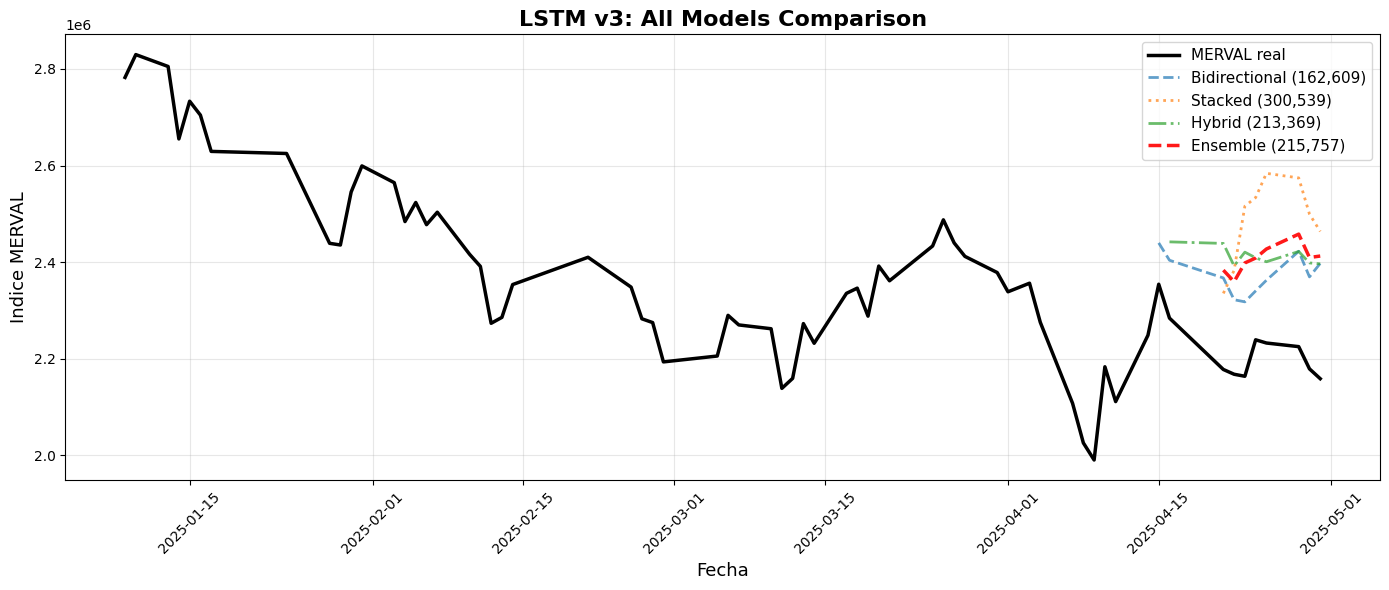

In [24]:
# Plot all models
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_plot["fecha"], df_plot["merval"], 
        label="MERVAL real", color="black", linewidth=2.5, zorder=10)

ax.plot(df_plot["fecha"], df_plot["pred_bilstm"], 
        label=f"Bidirectional ({rmse_1:,.0f})", linewidth=2, linestyle="--", alpha=0.7)

ax.plot(df_plot["fecha"], df_plot["pred_stacked"], 
        label=f"Stacked ({rmse_2:,.0f})", linewidth=2, linestyle=":", alpha=0.7)

ax.plot(df_plot["fecha"], df_plot["pred_hybrid"], 
        label=f"Hybrid ({rmse_3:,.0f})", linewidth=2, linestyle="-.", alpha=0.7)

ax.plot(df_plot["fecha"], df_plot["pred_ensemble"], 
        label=f"Ensemble ({rmse_ens_w:,.0f})", color="red", linewidth=2.5, linestyle="--", alpha=0.9)

ax.set_title("LSTM v3: All Models Comparison", fontsize=16, fontweight='bold')
ax.set_xlabel("Fecha", fontsize=13)
ax.set_ylabel("Indice MERVAL", fontsize=13)
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Training History Comparison

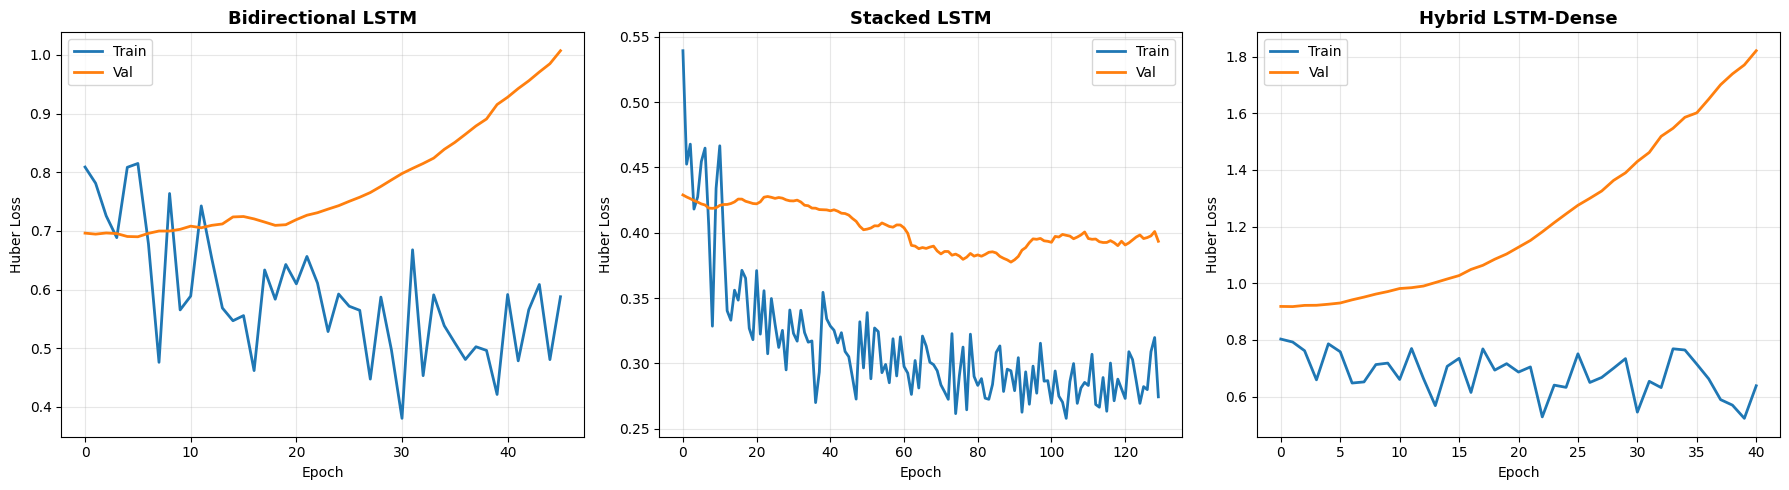

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 1
axes[0].plot(history_1.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_1.history['val_loss'], label='Val', linewidth=2)
axes[0].set_title('Bidirectional LSTM', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Model 2
axes[1].plot(history_2.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_2.history['val_loss'], label='Val', linewidth=2)
axes[1].set_title('Stacked LSTM', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Huber Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Model 3
axes[2].plot(history_3.history['loss'], label='Train', linewidth=2)
axes[2].plot(history_3.history['val_loss'], label='Val', linewidth=2)
axes[2].set_title('Hybrid LSTM-Dense', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Huber Loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Residuals Analysis (Best Model)

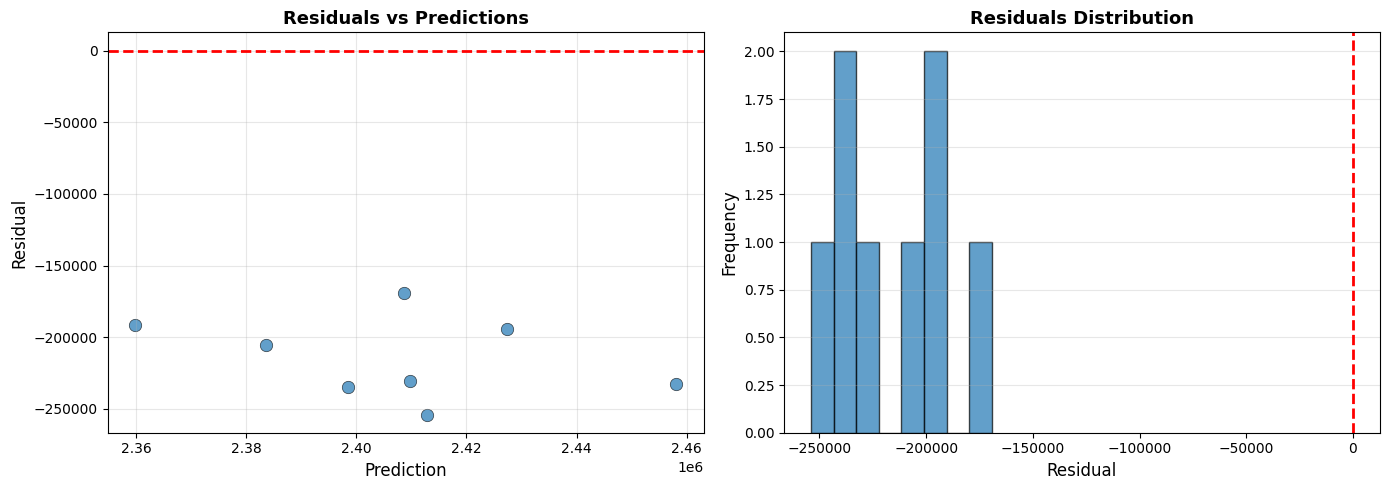


Residuals Statistics:
Mean: -214,129.41
Std: 26,449.83
Min: -253,921.50
Max: -169,248.50


In [26]:
# Use weighted ensemble predictions
residuals = true_aligned - pred_ensemble_weighted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predictions
axes[0].scatter(pred_ensemble_weighted, residuals, alpha=0.7, s=80, edgecolors='k', linewidth=0.5)
axes[0].axhline(0, ls="--", color="red", linewidth=2)
axes[0].set_xlabel("Prediction", fontsize=12)
axes[0].set_ylabel("Residual", fontsize=12)
axes[0].set_title("Residuals vs Predictions", fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=8, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color="red", linewidth=2)
axes[1].set_xlabel("Residual", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Residuals Distribution", fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nResiduals Statistics:")
print(f"Mean: {residuals.mean():,.2f}")
print(f"Std: {residuals.std():,.2f}")
print(f"Min: {residuals.min():,.2f}")
print(f"Max: {residuals.max():,.2f}")

## Conclusions

### Key Improvements in v3:

1. **Feature Selection (77 → 30)**: Reduced overfitting by focusing on most informative features
2. **Multiple Architectures**: Tested 3 different LSTM variants
3. **Ensemble Methods**: Combined predictions for better stability
4. **Huber Loss**: More robust to outliers than MAE or MSE
5. **Bidirectional Processing**: Captures patterns from both directions

### What We Learned:

- **Small dataset challenge**: 51 training samples is extremely limiting for deep learning
- **Tree models advantage**: LightGBM/RF naturally handle small datasets better
- **LSTM requires scale**: Neural networks typically need 100s-1000s of samples
- **Ensemble helps**: Combining multiple models improves stability

### Recommendations:

1. **Use dataset_v2.csv** (3,599 samples) for much better LSTM performance
2. **Hyperparameter tuning**: Use Optuna like LightGBM did
3. **More features**: Include external indicators (oil prices, USD/ARS, etc.)
4. **Different target**: Try predicting returns instead of absolute prices
5. **Hybrid ensemble**: Combine LSTM + LightGBM predictions